In [18]:
# run `uv sync` from terminal then select 'pandana_update_test (3.10)' kernel

import numpy as np
import pandas as pd
import pandana as pdna

In [19]:
edges = pd.read_csv('data/edges.csv')
nodes = pd.read_csv('data/nodes.csv').set_index('id')
blocks = pd.read_csv('data/blocks.csv').set_index('block_id')
households = pd.read_csv('data/households.csv').set_index('household_id')

In [20]:
# Build pandana network and map blocks to their nearest network node
net = pdna.Network(
    nodes['x'], nodes['y'], edges['from'], edges['to'], edges[['weight']],
    twoway=False)

precompute_distance = 1000
net.precompute(precompute_distance)

blocks['node_id'] = net.get_node_ids(blocks['x'], blocks['y'])

In [21]:
# Aggregate household-level variables to the block level
block_totals = pd.DataFrame(index=blocks.index)
block_totals['total_households'] = households.groupby('block_id').size()
block_totals['total_persons'] = households.groupby('block_id')['persons'].sum()
block_totals['total_workers'] = households.groupby('block_id')['workers'].sum()
block_totals['total_income'] = households.groupby('block_id')['income'].sum()
block_totals = block_totals.fillna(0)

blocks = blocks.join(block_totals)

In [22]:
# Compute 800m network accessibility variables (sum, flat decay)
radius = 800

for col in ['total_households', 'total_persons', 'total_workers', 'total_income']:
    net.set(blocks['node_id'], variable=blocks[col])
    access = net.aggregate(radius, type='sum', decay='flat')
    blocks[f'{col}_{radius}m'] = access.reindex(blocks['node_id']).values

# Derive average household income within the radius from the two summed variables
blocks[f'mean_income_{radius}m'] = (
    blocks[f'total_income_{radius}m'] / blocks[f'total_households_{radius}m']
).replace([np.inf, -np.inf], np.nan).fillna(0)

In [27]:
# Summary statistics for the new accessibility variables
access_cols = [
    'total_households_800m',
    'total_persons_800m',
    'total_workers_800m',
    'mean_income_800m',
]
blocks[access_cols].describe()

,total_households_800m,total_persons_800m,total_workers_800m,mean_income_800m
count,51420.000000,51420.000000,51420.000000,51420.000000
mean,251.859024,589.430805,365.919098,117145.329397
std,415.863336,773.268794,560.850401,59548.258202
min,0.000000,0.000000,0.000000,0.000000
25%,32.000000,82.000000,47.000000,85239.815806
50%,143.000000,372.000000,216.000000,116547.315891
75%,319.000000,822.000000,482.000000,151170.584287
max,8462.000000,12927.000000,10749.000000,780553.000000


In [24]:
# Visualization setup
from bokeh.io import output_notebook
import datashader as ds
import datashader.transfer_functions as tf
from datashader.colors import viridis

output_notebook()

def visualize_variable(df, variable_name, plot_width=1000, plot_height=700):
    cvs = ds.Canvas(plot_width=plot_width, plot_height=plot_height)
    agg = cvs.points(df, 'x', 'y', ds.mean(variable_name))
    img = tf.set_background(tf.shade(agg, cmap=viridis), "white")
    return img

Loading BokehJS ...

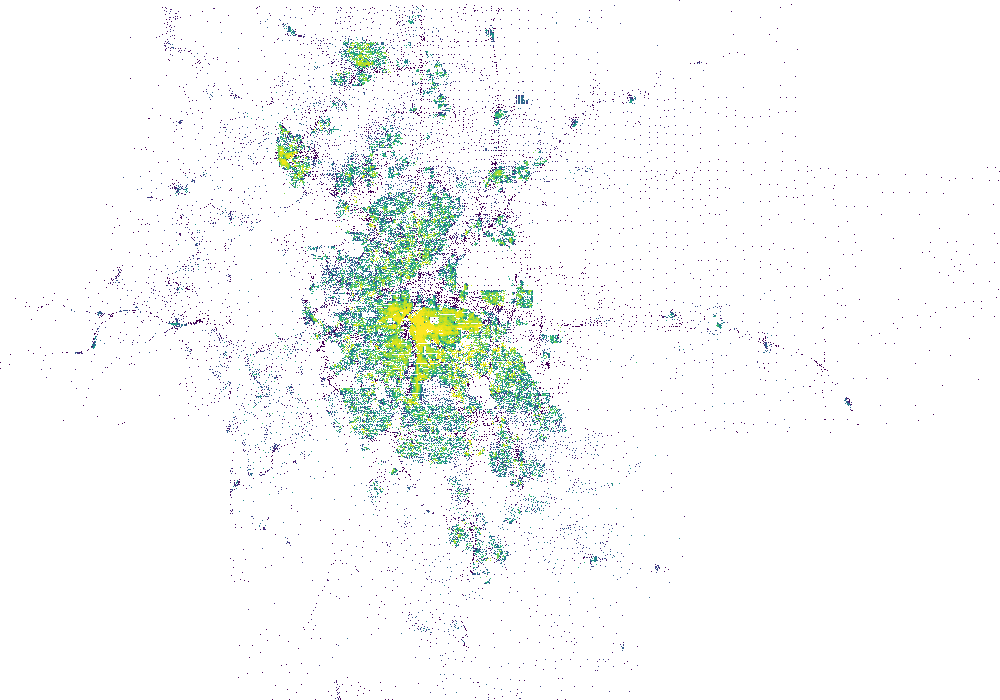

In [25]:
# Visualize total households accessible within 800m of each block
visualize_variable(blocks, 'total_households_800m')

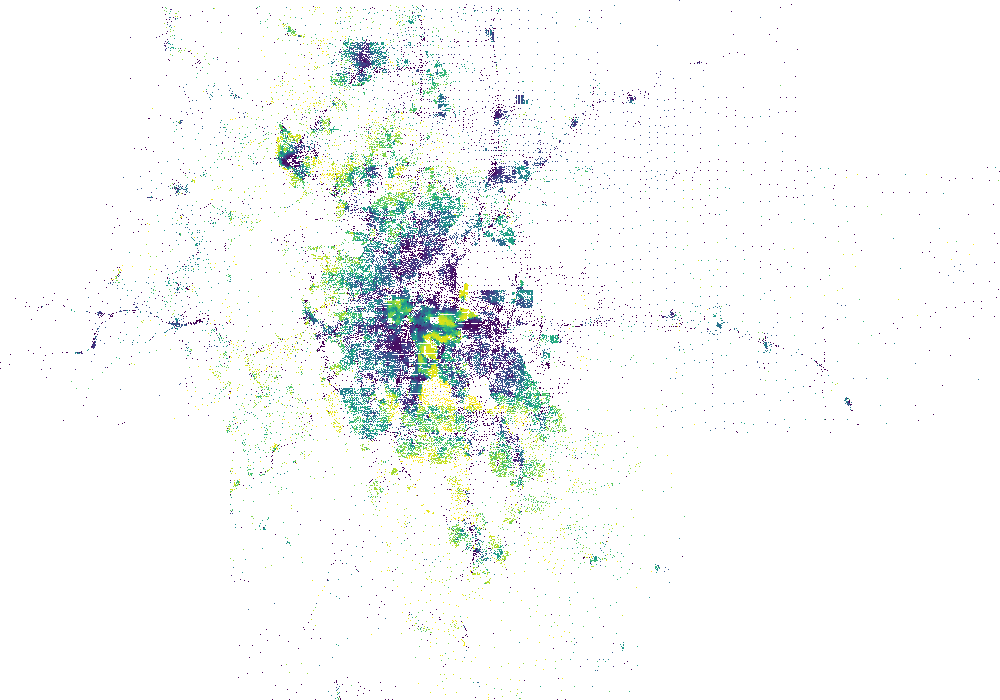

In [26]:
# Visualize average household income within 800m of each block
visualize_variable(blocks, 'mean_income_800m')